# Volatility and Risk Management for Daily Time Series


In this notebook, we work with the file `out28.csv` (high-frequency ticks: `day`, `tick`, `logprice`) and aggregate it into daily data. From the tick log-prices, we build **daily close-to-close returns** (R_d) and **daily realized variance** (RV_d). We then look at the main statistical features of these daily series (typical size, heavy tails, volatility clustering) before moving to two standard risk-management approaches: a **time-series volatility model** (AR(1)–GARCH(1,1)) and an **EVT tail model** (POT-GPD) for extreme losses. Finally, we compare their volatility and risk forecasts through simple out-of-sample style checks and VaR/ES diagnostics.




In [ ]:
import numpy as np
import pandas as pd

from scipy.stats import chi2, norm
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from scipy.linalg import solve_toeplitz


plt.rcParams['figure.figsize'] = (10, 4)

## 1. From tick data to daily series

We build:

- intraday log-returns `r_intraday`,
- daily realized variance `RV_d = \sum r_{d,i}^2`,
- daily log-returns `R_d` from last log-price of each day.

The function `load_ticks` is robust to the presence of a header line and
forces the three columns to be numeric.

In [ ]:
def load_ticks(path: str) -> pd.DataFrame:
    """Load tick data and ensure numeric columns day, tick, logprice.
    """
    df = pd.read_csv(path, low_memory=False)

    # Standardise column names (lowercase)
    df.columns = [str(c).strip().lower() for c in df.columns]

    # Keep only the three relevant columns (in the right order)
    df = df[["day", "tick", "logprice"]]

    # Convert to numeric and drop non-numeric rows (e.g. header accidentally read as data)
    df["day"] = pd.to_numeric(df["day"], errors="coerce").astype("Int64")
    df["tick"] = pd.to_numeric(df["tick"], errors="coerce")
    df["logprice"] = pd.to_numeric(df["logprice"], errors="coerce")

    df = df.dropna(subset=["day", "tick", "logprice"]).reset_index(drop=True)
    df["day"] = df["day"].astype(int)

    # Sort by day then tick
    df = df.sort_values(["day", "tick"]).reset_index(drop=True)
    return df


def compute_intraday_returns(df: pd.DataFrame) -> pd.DataFrame:
    """Add intraday log-returns r_intraday = diff(logprice) per day."""
    df = df.copy()

    def intraday_returns(group: pd.DataFrame) -> pd.Series:
        return group["logprice"].diff()

    df["r_intraday"] = df.groupby("day", group_keys=False).apply(intraday_returns)
    return df


def compute_realized_volatility(df: pd.DataFrame) -> pd.Series:
    """Realized variance per day: RV_d = sum_i r_{d,i}^2."""
    rv = (
        df.dropna(subset=["r_intraday"])
          .groupby("day")["r_intraday"]
          .apply(lambda x: np.sum(x.values**2))
    )
    rv.name = "RV"
    return rv


def compute_daily_returns(df: pd.DataFrame) -> pd.Series:
    """Daily log-returns from last logprice of each day."""
    close_logprice = df.groupby("day")["logprice"].last()
    R = close_logprice.diff().dropna()
    R.name = "R"
    return R


def build_daily_series(path: str):
    """from tick file to aligned daily R and RV."""
    df = load_ticks(path)
    df = compute_intraday_returns(df)
    RV = compute_realized_volatility(df)
    R = compute_daily_returns(df)
    daily = pd.concat([R, RV], axis=1).dropna()
    return daily, df

## 2. Statistical Analysis of Daily Returns

We compute empirical moments, Jarque–Bera normality test, ACF and Ljung–Box statistics.

In [ ]:
def empirical_moments(x: np.ndarray) -> dict:
    """Return mean, variance, skewness, kurtosis, JB statistic and p-value."""
    x = np.asarray(x)
    n = x.size
    mean = x.mean()
    var = ((x - mean)**2).sum() / (n - 1)
    sigma = np.sqrt(var)
    skew = ((x - mean)**3).sum() / (n * sigma**3)
    kurt = ((x - mean)**4).sum() / (n * sigma**4)
    JB = n * (skew**2 / 6.0 + (kurt - 3.0)**2 / 24.0)
    p_JB = 1 - chi2.cdf(JB, df=2)
    return {
        "mean": mean,
        "var": var,
        "skew": skew,
        "kurt": kurt,
        "JB": JB,
        "JB_pvalue": p_JB,
    }


def acf(x: np.ndarray, max_lag: int) -> np.ndarray:
    """Empirical autocorrelation up to max_lag."""
    x = np.asarray(x)
    n = x.size
    mean = x.mean()
    gamma0 = ((x - mean)**2).sum() / n
    acf_vals = np.empty(max_lag + 1)
    acf_vals[0] = 1.0
    for k in range(1, max_lag + 1):
        cov = ((x[k:] - mean) * (x[:-k] - mean)).sum() / n
        acf_vals[k] = cov / gamma0
    return acf_vals


def ljung_box(x: np.ndarray, K: int):
    """Ljung–Box Q statistic and p-value for lags 1..K."""
    x = np.asarray(x)
    n = x.size
    rho = acf(x, K)[1:]  # lags 1..K
    Q1 = n * (n + 2) * np.sum(rho**2 / (n - np.arange(1, K + 1)))
    pval = 1 - chi2.cdf(Q1, df=K)
    return Q1, pval

## 3. Time series model: AR(1)–GARCH(1,1)

We first fit an AR(1) in the conditional mean, then a GARCH(1,1) for the conditional variance.

In [ ]:
def fit_ar1(R: np.ndarray):
    """Fit AR(1): R_t - mu = phi (R_{t-1} - mu) + eps_t.
    Returns (mu_hat, phi_hat, eps), with eps starting at t=1.
    """
    R = np.asarray(R)
    n = R.size
    R_bar = R.mean()
    R_lag = R[:-1]
    R_curr = R[1:]
    num = ((R_curr - R_bar) * (R_lag - R_bar)).sum()
    den = ((R_lag - R_bar)**2).sum()
    phi_hat = num / den
    mu_hat = R_bar
    eps = np.empty(n)
    eps[0] = 0.0
    for t in range(1, n):
        eps[t] = R[t] - mu_hat - phi_hat * (R[t-1] - mu_hat)
    return mu_hat, phi_hat, eps[1:]


def garch_neg_loglik(params, eps: np.ndarray) -> float:
    """Negative conditional log-likelihood for GARCH(1,1)."""
    omega, alpha, beta = params
    if omega <= 0 or alpha < 0 or beta < 0 or (alpha + beta) >= 1:
        return 1e10
    eps = np.asarray(eps)
    n = len(eps)
    sigma2 = np.empty(n)
    sigma2[0] = np.var(eps)
    for t in range(1, n):
        sigma2[t] = omega + alpha * eps[t-1]**2 + beta * sigma2[t-1]
        if sigma2[t] <= 0:
            return 1e10
    ll = -0.5 * np.sum(np.log(2 * np.pi) + np.log(sigma2) + eps**2 / sigma2)
    return -ll


def fit_garch11(eps: np.ndarray):
    """Fit GARCH(1,1) by numerical maximisation of conditional log-likelihood."""
    eps = np.asarray(eps)
    init = np.array([0.1 * np.var(eps), 0.05, 0.9])
    bounds = [(1e-8, None), (0.0, 1.0), (0.0, 1.0)]
    res = minimize(garch_neg_loglik, init, args=(eps,), method="L-BFGS-B", bounds=bounds)
    omega_hat, alpha_hat, beta_hat = res.x
    n = len(eps)
    sigma2_hat = np.empty(n)
    sigma2_hat[0] = np.var(eps)
    for t in range(1, n):
        sigma2_hat[t] = omega_hat + alpha_hat * eps[t-1]**2 + beta_hat * sigma2_hat[t-1]
    return omega_hat, alpha_hat, beta_hat, sigma2_hat


def forecast_sigma2_one_step(eps: np.ndarray, sigma2: np.ndarray,
                             omega: float, alpha: float, beta: float) -> np.ndarray:
    """One-step-ahead forecasts sigma_{t+1|t}^2 for t=0..n-2."""
    n = len(eps)
    sigma2_forecast = np.empty(n - 1)
    for t in range(n - 1):
        sigma2_forecast[t] = omega + alpha * eps[t]**2 + beta * sigma2[t]
    return sigma2_forecast


def evaluate_vol_forecasts(sigma2_forecast: np.ndarray, RV_next: np.ndarray):
    """Return MSE and MAD between volatility forecasts and next-day realized volatility."""
    mse = np.mean((sigma2_forecast - RV_next)**2)
    mad = np.mean(np.abs(sigma2_forecast - RV_next))
    return mse, mad

## 4. Extreme Value Theory: GPD for losses

We fit a Generalized Pareto Distribution (GPD) to excess losses over a high threshold.

In [ ]:
def fit_gpd_MLE(excess: np.ndarray):
    """MLE for GPD(sigma_u, xi) on strictly positive excesses."""
    excess = np.asarray(excess)

    def gpd_negloglik(params):
        sigma, xi = params
        if sigma <= 0:
            return 1e10
        z = 1 + xi * excess / sigma
        if np.any(z <= 0):
            return 1e10
        n = len(excess)
        ll = -n * np.log(sigma) - (1 + 1 / xi) * np.sum(np.log(z))
        return -ll

    init = np.array([excess.mean(), 0.1])
    res = minimize(gpd_negloglik, init, method="L-BFGS-B")
    sigma_hat, xi_hat = res.x
    return sigma_hat, xi_hat


def var_es_gpd(alpha: float, u: float, p_u: float,
               sigma_u: float, xi: float):
    """VaR and ES for losses using GPD POT formulas."""
    q_alpha = u + sigma_u / xi * ((p_u / (1 - alpha))**xi - 1)
    ES_alpha = q_alpha + (sigma_u + xi * (q_alpha - u)) / (1 - xi)
    return q_alpha, ES_alpha

## 5. VaR/ES from GARCH–Normal and from EVT

We compute one-step-ahead VaR assuming conditional normality of returns, and compare with EVT-based VaR/ES.

In [ ]:
def one_step_sigma_next(eps_last: float, sigma2_last: float,
                         omega: float, alpha: float, beta: float) -> float:
    """Next-day conditional standard deviation from GARCH(1,1)."""
    return np.sqrt(omega + alpha * eps_last**2 + beta * sigma2_last)


def var_garch_normal(mu: float, sigma_next: float, alpha_lvl: float):
    """VaR for returns and losses under conditional Normal(mu, sigma_next^2)."""
    z_alpha = norm.ppf(alpha_lvl)
    VaR_ret = mu + sigma_next * z_alpha
    VaR_loss = -VaR_ret
    return VaR_loss, VaR_ret


def backtest_var(loss: np.ndarray, var_series: np.ndarray):
    """Return exceedance frequency and indicator array for a VaR series."""
    loss = np.asarray(loss)
    var_series = np.asarray(var_series)
    I = (loss > var_series).astype(int)
    freq = I.mean()
    return freq, I

## 6. Analysis

The following cells run the analysis.



### 6.1 Load tick data and build daily R and RV

In [ ]:
daily, df_ticks = build_daily_series("out28.csv")  # adapt path if needed
R_daily = daily["R"].values
RV_daily = daily["RV"].values
print(f"Number of daily observations: {len(R_daily)}")
daily.head()

/tmp/ipython-input-2125674848.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df["r_intraday"] = df.groupby("day", group_keys=False).apply(intraday_returns)


Number of daily observations: 753


,R,RV
day,,
2,0.013904,0.000083
3,0.008506,0.000103
4,0.002202,0.000086
5,0.000463,0.000101
6,0.006689,0.000074


The two daily series we obtain are:

* the **log-returns (R_t)**, which fluctuate around zero with a few larger moves;
* the **realized variance (RV_t)**, built from intraday returns.

A classic pattern already appears: the returns themselves do not look very persistent, but the realized variance shows **quiet periods** and **high-volatility periods**, which suggests the usual **volatility clustering** seen in financial data.


### 6.2 Exploratory Data Analysis on daily returns

Empirical moments for daily returns:
  mean: 0.0012118016439450184
  var: 0.00012320112784036931
  skew: 0.16480973957792913
  kurt: 4.922588818087594
  JB: 119.3817734853853
  JB_pvalue: 0.0
Ljung-Box Q (returns): 15.579, p-value=0.1123
Ljung-Box Q (squared returns): 24.887, p-value=0.0056


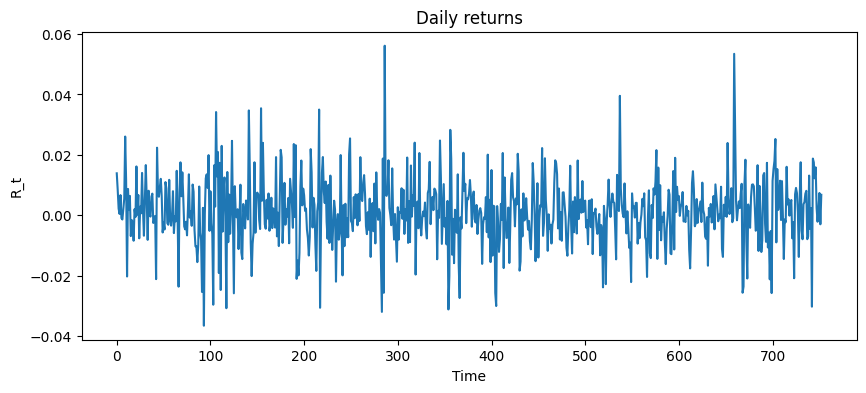

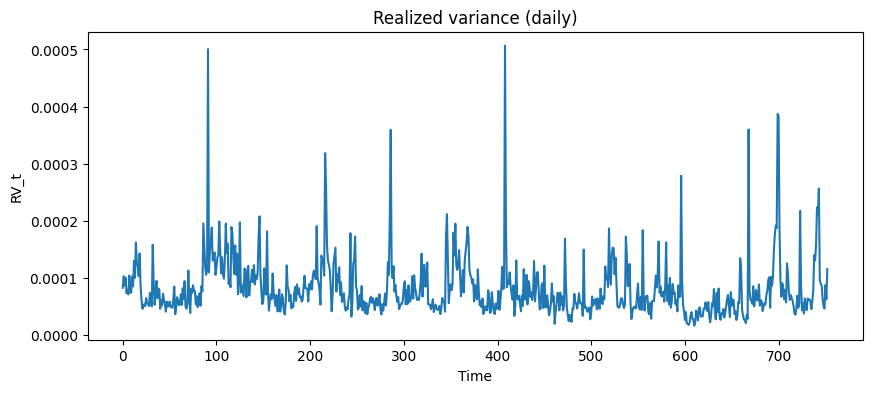

In [ ]:
mom = empirical_moments(R_daily)
print("Empirical moments for daily returns:")
for k, v in mom.items():
    print(f"  {k}: {v}")

rho_R = acf(R_daily, max_lag=20)
Q1_R, p_R = ljung_box(R_daily, K=10)
print(f"Ljung-Box Q (returns): {Q1_R:.3f}, p-value={p_R:.4f}")

rho_R2 = acf(R_daily**2, max_lag=20)
Q1_R2, p_R2 = ljung_box(R_daily**2, K=10)
print(f"Ljung-Box Q (squared returns): {Q1_R2:.3f}, p-value={p_R2:.4f}")

plt.figure(); plt.plot(R_daily)
plt.title("Daily returns"); plt.xlabel("Time"); plt.ylabel("R_t"); plt.show()

plt.figure(); plt.plot(RV_daily)
plt.title("Realized variance (daily)"); plt.xlabel("Time"); plt.ylabel("RV_t"); plt.show()

The empirical moments show a **small but slightly positive daily mean** (around 0.12%), a standard deviation of about 1.1%, and most importantly a **kurtosis close to 5**, well above 3. The Jarque–Bera test strongly rejects normality, which confirms the presence of **fat tails**.

The Ljung–Box tests indicate no significant autocorrelation in the returns themselves, but a clear dependence in **squared returns**, which is consistent with the idea of a time-varying (conditional) volatility.


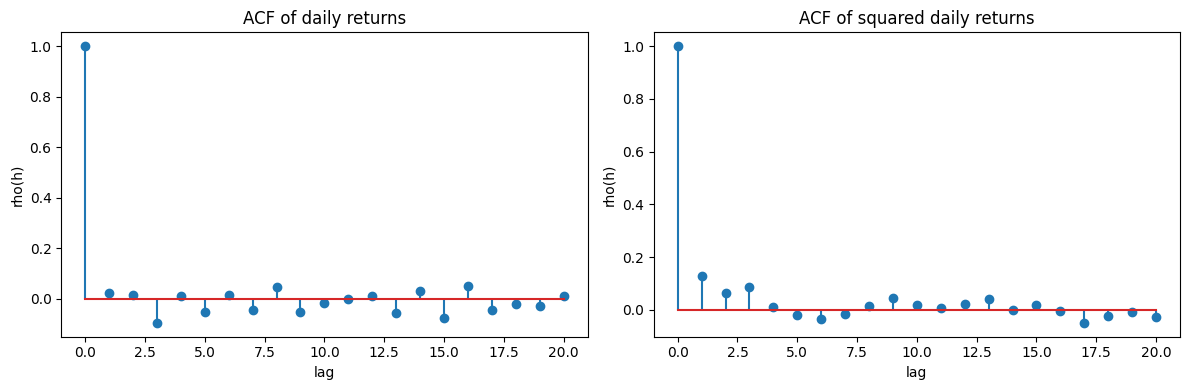

In [ ]:
#ACF diagnostics

max_lag = 20
lags = np.arange(max_lag + 1)

# ACF of returns and squared returns
rho_R = acf(R_daily, max_lag=max_lag)
rho_R2 = acf(R_daily**2, max_lag=max_lag)

# Plots: ACF(R_t) and ACF(R_t^2)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ACF(R_t)
axes[0].stem(lags, rho_R)
axes[0].set_title("ACF of daily returns")
axes[0].set_xlabel("lag")
axes[0].set_ylabel("rho(h)")

# ACF(R_t^2)
axes[1].stem(lags, rho_R2)
axes[1].set_title("ACF of squared daily returns")
axes[1].set_xlabel("lag")
axes[1].set_ylabel("rho(h)")

plt.tight_layout()
plt.show()

The ACF plots confirm these results:

- the ACF of **returns $R_t$** is close to zero from the first lag, meaning returns are almost uncorrelated;
- the ACF of **squared returns $R_t^2$** is clearly positive for the first lags, which highlights **volatility clustering**.

This diagnostic supports using a very simple model for the mean (an almost flat AR(1)) and a **GARCH(1,1)** model for the conditional variance.


### 6.3 Fit AR(1) and GARCH(1,1)

In [ ]:
mu_hat, phi_hat, eps = fit_ar1(R_daily)
omega_hat, alpha_hat, beta_hat, sigma2_hat = fit_garch11(eps)
print("AR(1) parameters: mu=", mu_hat, "phi=", phi_hat)
print("GARCH(1,1) parameters: omega=", omega_hat,
      "alpha=", alpha_hat, "beta=", beta_hat,
      "alpha+beta=", alpha_hat + beta_hat)

AR(1) parameters: mu= 0.0012118016439450184 phi= 0.022885581826361027
GARCH(1,1) parameters: omega= 1.9652660935483356e-05 alpha= 0.04402750010094973 beta= 0.79249491011612 alpha+beta= 0.8365224102170697


For the conditional mean, the estimated AR(1) coefficient ($\phi \approx 0.02$) is very small: returns have **very little memory** and behave almost like white noise around their average.

For the conditional variance, the GARCH(1,1) model gives $\alpha \approx 0.04$ and $\beta \approx 0.79$, with $\alpha + \beta \approx 0.84 < 1$. The stationarity condition is therefore satisfied, and volatility is **persistent** without being extremely slow to revert to its long-run level. This specification is consistent with the volatility clustering observed in the realized variance.



Standardised residuals (eps_t / sigma_t):
  mean: -0.007511611490293378
  var: 1.0065952727954164
  skew: 0.17225110319177003
  kurt: 4.816415030125218
  JB: 107.09875373186162
  JB_pvalue: 0.0
Ljung-Box Q (z_t): 12.218, p-value=0.2708
Ljung-Box Q (z_t^2): 10.138, p-value=0.4285


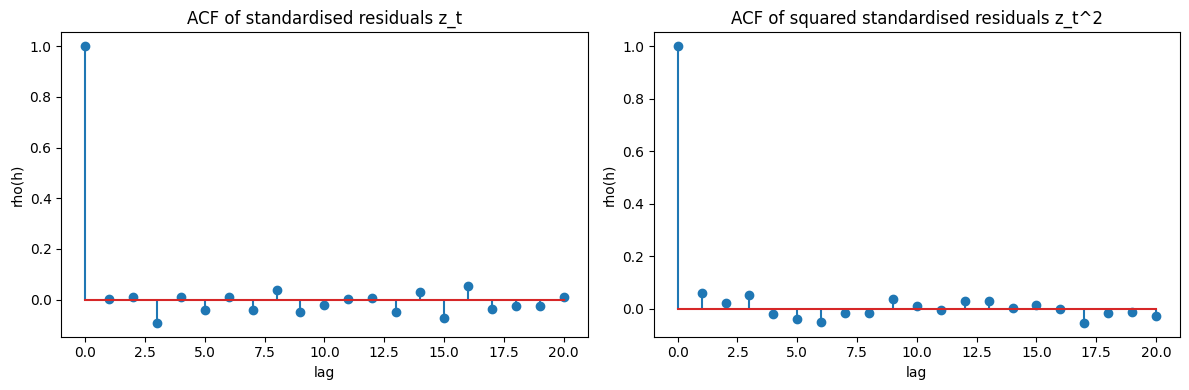

In [ ]:

# Standardized residuals
z_hat = eps / np.sqrt(sigma2_hat)

mom_z = empirical_moments(z_hat)
print("\nStandardised residuals (eps_t / sigma_t):")
for k, v in mom_z.items():
    print(f"  {k}: {v}")

Qz, pz = ljung_box(z_hat, K=10)
Qz2, pz2 = ljung_box(z_hat**2, K=10)
print(f"Ljung-Box Q (z_t): {Qz:.3f}, p-value={pz:.4f}")
print(f"Ljung-Box Q (z_t^2): {Qz2:.3f}, p-value={pz2:.4f}")

# ACF of standardized residuals and their squares
max_lag = 20
lags = np.arange(max_lag + 1)
rho_z = acf(z_hat, max_lag=max_lag)
rho_z2 = acf(z_hat**2, max_lag=max_lag)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].stem(lags, rho_z)
axes[0].set_title("ACF of standardised residuals z_t")
axes[0].set_xlabel("lag")
axes[0].set_ylabel("rho(h)")

axes[1].stem(lags, rho_z2)
axes[1].set_title("ACF of squared standardised residuals z_t^2")
axes[1].set_xlabel("lag")
axes[1].set_ylabel("rho(h)")

plt.tight_layout()
plt.show()


The standardized residuals $z_t = \hat{\varepsilon}_t / \hat{\sigma}_t$ have a mean close to 0 and a variance close to 1, which shows that scaling by the conditional volatility works well. However, the Jarque–Bera test still rejects normality (kurtosis $\approx 4.8$), indicating **heavier tails than the conditional normal distribution**.

From a time-series perspective, the Ljung–Box tests on $z_t$ and $z_t^2$ do not reject the absence of autocorrelation, and their ACFs are almost flat. Overall, the AR(1)–GARCH(1,1) model **removes the serial dependence in the variance quite effectively**, even though the conditional distribution remains non-Gaussian.


### 6.4 Volatility forecasts vs realized volatility

Volatility forecast MSE=3.9256e-09, MAD=5.2905e-05
Correlation between RV_(t+1) and GARCH forecast sigma^2_(t+1|t): 0.312


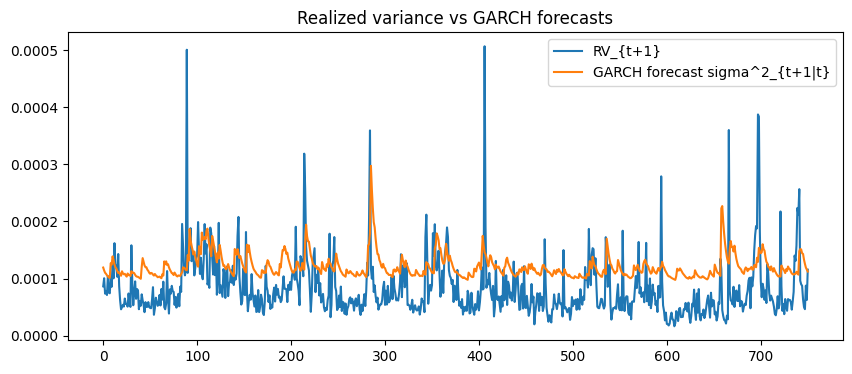

In [ ]:
RV_aligned = RV_daily[1:]  # align with eps
sigma2_forecast = forecast_sigma2_one_step(eps, sigma2_hat, omega_hat, alpha_hat, beta_hat)
RV_next = RV_aligned[1:]
# Removed: sigma2_forecast = sigma2_forecast[:-1] - This line caused the length mismatch.
mse, mad = evaluate_vol_forecasts(sigma2_forecast, RV_next)
print(f"Volatility forecast MSE={mse:.4e}, MAD={mad:.4e}")
# Corrélation entre volatilité réalisée et prévision GARCH
corr = np.corrcoef(RV_next, sigma2_forecast)[0, 1]
print(f"Correlation between RV_(t+1) and GARCH forecast sigma^2_(t+1|t): {corr:.3f}")


plt.figure();
plt.plot(RV_next, label="RV_{t+1}")
plt.plot(sigma2_forecast, label="GARCH forecast sigma^2_{t+1|t}")
plt.legend(); plt.title("Realized variance vs GARCH forecasts"); plt.show()

The conditional variance predicted by the GARCH model follows the **next-day realized variance** reasonably well (correlation ≈ 0.31). The forecast is smoother than the realized series, but it still captures the main high-volatility episodes, which is what matters for risk management.


### 6.5 EVT: GPD fit and VaR/ES

In [ ]:
L = -R_daily
q_threshold = 0.95
u = np.quantile(L, q_threshold)
excess = L[L > u] - u
n = len(L)
n_u = len(excess)
p_u = n_u / n
print(f"Threshold u={u:.6f}, number of exceedances={n_u} ({p_u:.2%} of data)")

sigma_u_hat, xi_hat = fit_gpd_MLE(excess)
print("GPD parameters: sigma_u=", sigma_u_hat, "xi=", xi_hat)

alpha_lvl = 0.99
VaR_loss_evt, ES_loss_evt = var_es_gpd(alpha_lvl, u, p_u, sigma_u_hat, xi_hat)
print(f"EVT VaR (loss) at {alpha_lvl:.2%}: {VaR_loss_evt:.6f}")
print(f"EVT ES  (loss) at {alpha_lvl:.2%}: {ES_loss_evt:.6f}")

Threshold u=0.017498, number of exceedances=38 (5.05% of data)
GPD parameters: sigma_u= 0.009421763604653851 xi= -0.44810004602828646
EVT VaR (loss) at 99.00%: 0.028344
EVT ES  (loss) at 99.00%: 0.031494


In [ ]:
# Simple backtest of the EVT VaR on the full sample
I_evt = (L > VaR_loss_evt).astype(int)
freq_evt = I_evt.mean()
print(f"EVT VaR exceedances on full sample: {I_evt.sum()} out of {len(L)} "
      f"({freq_evt:.2%}, target 1.00%)")


EVT VaR exceedances on full sample: 8 out of 753 (1.06%, target 1.00%)


In EVT, we retain the 95th percentile of losses as the threshold (u ≈ 1.75%), which leaves 38 exceedances, i.e. about 5% of the observations, in the range recommended for the POT approach.

The GPD fit provides a negative shape parameter (ξ ≈ −0.45), suggesting a **relatively short tail** over the period studied, and leads to an EVT VaR at 99% of about 2.83% and an ES at 99% of about 3.15%. The simple backtest shows 8 exceedances over 753 days (≈ 1.06%), very close to the nominal 1% level. The **tail calibration** by the GPD therefore appears reasonable in-sample.


### 6.6 One-step-ahead GARCH–Normal VaR

In [ ]:
### 6.6 One-step-ahead GARCH–Normal VaR

alpha_tail = 0.01   # 1% left-quantile of returns = 99% VaR for losses
eps_last = eps[-1]
sigma2_last = sigma2_hat[-1]
# One-step-ahead conditional volatility from the fitted GARCH(1,1)
sigma_next = one_step_sigma_next(eps_last, sigma2_last, omega_hat, alpha_hat, beta_hat)

# Standard Normal quantile at 1% (negative value)
z_alpha = norm.ppf(alpha_tail)

# Conditional VaR for returns under Normal innovations

VaR_ret_garch = mu_hat + sigma_next * z_alpha   # quantile of returns
VaR_loss_garch = -VaR_ret_garch                 #  convert to loss VaR (positive number)

print(f"GARCH-Normal one-step VaR (loss) at 99.00%: {VaR_loss_garch:.6f}")


GARCH-Normal one-step VaR (loss) at 99.00%: 0.023192


Assuming normally distributed innovations, the **99% GARCH–Normal VaR** for the last day of the sample is about **2.3%**. This is **lower** than the **EVT VaR** (≈ **2.8%**), which is consistent with the idea that the normal distribution tends to **underestimate extreme events** compared with an EVT tail model that is specifically designed to capture tail risk.


### 6.7 Simple VaR comparison: GARCH vs EVT (99%)



99% VaR backtesting on daily losses (t = 1..N-1):
  GARCH-Normal: exceedances = 15 / 752 (1.99%, target 1.00%)
  EVT (GPD):    exceedances = 8 / 752 (1.06%, target 1.00%)


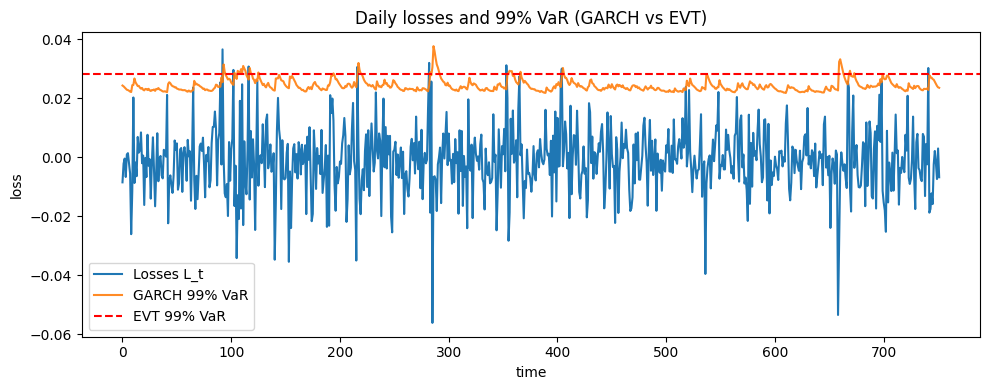

In [ ]:
# 6.7 Simple VaR comparison: GARCH vs EVT (99%)

alpha_tail = 0.01
z_alpha = norm.ppf(alpha_tail)  # < 0

# Work on t = 1..N-1 (we lose the very first day because of lag/diff alignment)
R_trunc = R_daily[1:]      # R_1,...,R_{N-1}
R_lag   = R_daily[:-1]     # R_0,...,R_{N-2}
L_trunc = -R_trunc         # losses

# Conditional volatility series (same length as eps_t, i.e. N-1 here)
sigma_t = np.sqrt(sigma2_hat)

# AR(1) conditional mean: E[R_t | R_{t-1}] = mu + phi (R_{t-1} - mu)
mu_t = mu_hat + phi_hat * (R_lag - mu_hat)

# GARCH-Normal VaR for each day t=1..N-1
VaR_ret_garch_series = mu_t + sigma_t * z_alpha
VaR_loss_garch_series = -VaR_ret_garch_series

# EVT VaR is constant over the full period (already computed above)
VaR_loss_evt_series = np.full_like(L_trunc, VaR_loss_evt)

# Exceedance frequencies (how often loss > VaR)
freq_garch, I_garch = backtest_var(L_trunc, VaR_loss_garch_series)
freq_evt2, I_evt2   = backtest_var(L_trunc, VaR_loss_evt_series)

print("\n99% VaR backtesting on daily losses (t = 1..N-1):")
print(f"  GARCH-Normal: exceedances = {I_garch.sum()} / {len(L_trunc)} "
      f"({freq_garch:.2%}, target 1.00%)")
print(f"  EVT (GPD):    exceedances = {I_evt2.sum()} / {len(L_trunc)} "
      f"({freq_evt2:.2%}, target 1.00%)")

# Plot: losses vs VaR lines.
plt.figure(figsize=(10, 4))
plt.plot(L_trunc, label="Losses L_t")  # check L_trunc = -R_trunc
plt.plot(VaR_loss_garch_series, label="GARCH 99% VaR", alpha=0.9)
plt.axhline(y=VaR_loss_evt, color="red", linestyle="--", label="EVT 99% VaR")
plt.title("Daily losses and 99% VaR (GARCH vs EVT)")
plt.xlabel("time")
plt.ylabel("loss")
plt.legend()
plt.tight_layout()
plt.show()



Over the full sample period, the 99% VaR based on an AR(1)–GARCH(1,1) model with Gaussian innovations produces **15 exceedances over 752 days**, i.e. about **2%**, which is almost twice the nominal 1% level. In contrast, the 99% VaR obtained from EVT (POT–GPD) yields **8 exceedances** (≈ **1.1%**), which is very close to the expected frequency.

The plot of daily losses shows that losses cross the GARCH VaR band more often than the EVT VaR line, since the EVT VaR is higher and therefore more **conservative**. We conclude that the **GARCH model captures volatility dynamics well**, but it tends to **underestimate extreme tail risk** under the normality assumption, whereas EVT provides a **better-calibrated tail risk measure** for risk management.
